In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("car_data.csv")

In [70]:
df['Car_Age'] = 2026 - df['Year']

In [72]:
features = [
    'Car_Age', 
    'Present_Price', 
    'Driven_kms', 
    'Owner', 
    'Fuel_Type', 
    'Transmission', 
    'Selling_type', 
    'Selling_Price'
]
df_filtered = df[features]

In [74]:
df_encoded = pd.get_dummies(df_filtered, drop_first=True)

In [76]:
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [78]:
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [83]:
predictions = model.predict(X_test)

In [86]:
accuracy = r2_score(y_test, predictions)
accuracy

0.959831047909005

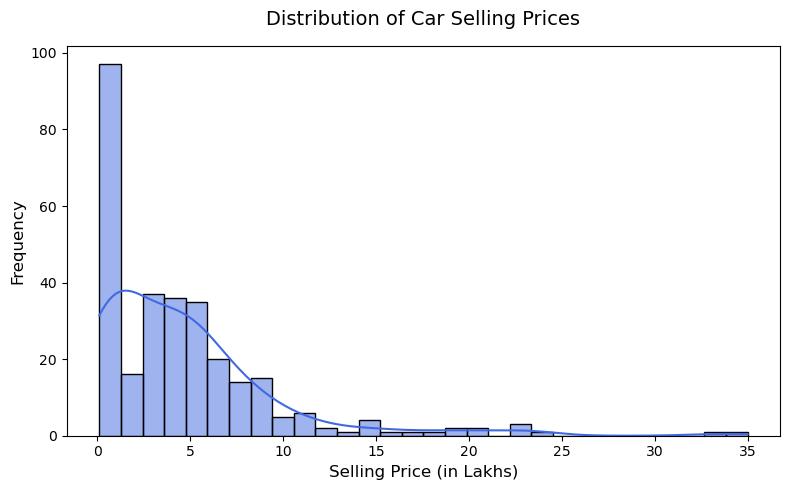

In [93]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Car Selling Prices', fontsize=14, pad=15)
plt.xlabel('Selling Price (in Lakhs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('eda_selling_price_distribution.png')
plt.show()

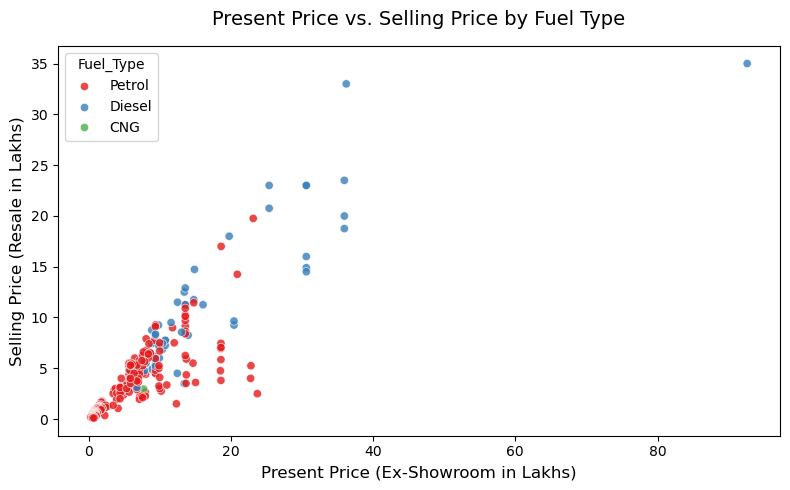

In [95]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, hue='Fuel_Type', palette='Set1', alpha=0.8)
plt.title('Present Price vs. Selling Price by Fuel Type', fontsize=14, pad=15)
plt.xlabel('Present Price (Ex-Showroom in Lakhs)', fontsize=12)
plt.ylabel('Selling Price (Resale in Lakhs)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_present_vs_selling_price.png')
plt.show()

In [99]:
import pickle

In [103]:
with open('car_prediction.pkl','wb') as f:
    pickle.dump(model,f)